<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 162.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 163.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 168.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [4]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [5]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [8]:
# 1. Подсчет количества полных дубликатов строк
duplicate_count = df.duplicated().sum()
print("Количество строк-дубликатов:", duplicate_count)

# 2. Вывод первых нескольких строк-дубликатов для анализа
duplicate_rows = df[df.duplicated()]
duplicate_rows.head()

Количество строк-дубликатов: 0

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat


### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [9]:
# 1. Идентификация шаблонов по выбранным колонкам и подсчет их частоты
selected_cols = ['MainBranch', 'Employment', 'RemoteWork']
patterns = df.groupby(selected_cols).size().reset_index(name='Count')

# Сортируем по убыванию частоты, чтобы увидеть самые популярные шаблоны ответов
patterns_sorted = patterns.sort_values(by='Count', ascending=False)
print("Самые частые шаблоны ответов:")
print(patterns_sorted.head())

# 2. Поиск других колонок, которые часто совпадают (например, Country и YearsCode)
extended_cols = selected_cols + ['Country', 'YearsCode']
patterns_extended = df.groupby(extended_cols).size().reset_index(name='Count').sort_values(by='Count', ascending=False)
print("\nШаблоны с учетом Country и YearsCode:")
print(patterns_extended.head())

Самые частые шаблоны ответов:
                        MainBranch  \
0   I am a developer by profession   
2   I am a developer by profession   
1   I am a developer by profession   
78  I am a developer by profession   
8   I am a developer by profession   

                                           Employment  \
0                                 Employed, full-time   
2                                 Employed, full-time   
1                                 Employed, full-time   
78  Independent contractor, freelancer, or self-em...   
8   Employed, full-time;Independent contractor, fr...   

                              RemoteWork  Count  
0   Hybrid (some remote, some in-person)  15286  
2                                 Remote  12191  
1                              In-person   7118  
78                                Remote   2814  
8                                 Remote   1754  

Шаблоны с учетом Country и YearsCode:
                          MainBranch           Employment  

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


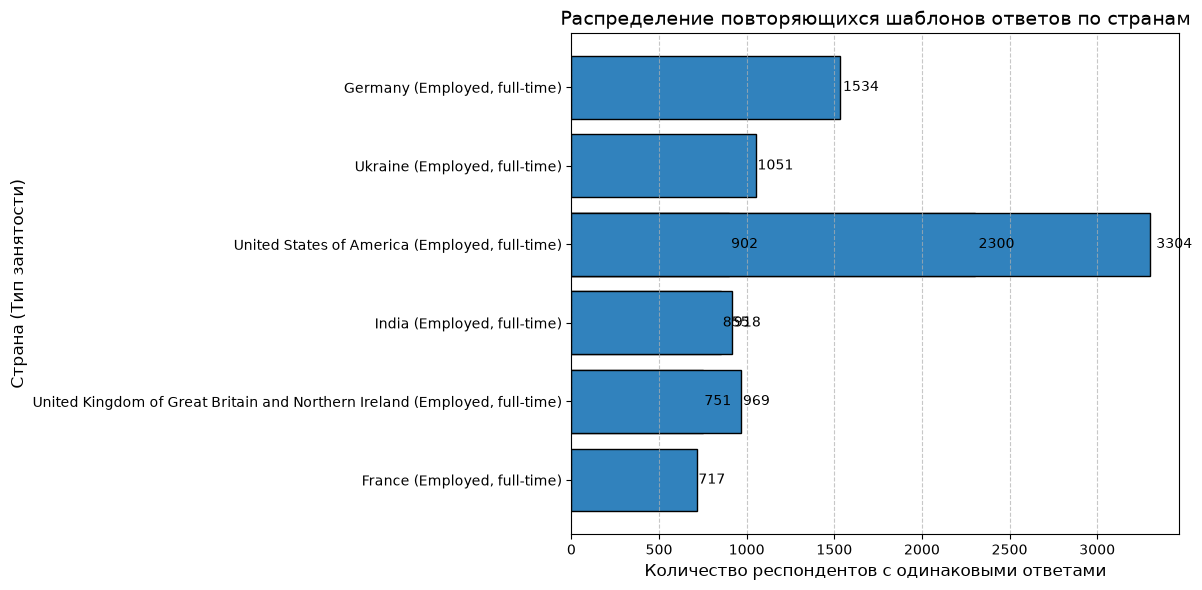

In [12]:
# 1. Агрегируем данные для топ-10 комбинаций
selected_cols = ['MainBranch', 'Employment', 'RemoteWork']
top_patterns = df.groupby(['Country'] + selected_cols).size().reset_index(name='Respondents')
top_patterns = top_patterns.sort_values(by='Respondents', ascending=False).head(10)

# 2. Создаем подписи для оси Y, объединяя страну и тип занятости респондента
labels = [f"{row['Country']} ({row['Employment']})" for _, row in top_patterns.iterrows()]
values = top_patterns['Respondents'].tolist()

# 3. Строим горизонтальный столбчатый график средствами чистого matplotlib
plt.figure(figsize=(12, 6))
bars = plt.barh(labels[::-1], values[::-1], color='#3182bd', edgecolor='black')

# Добавляем сетку и подписи
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.title('Распределение повторяющихся шаблонов ответов по странам', fontsize=14)
plt.xlabel('Количество респондентов с одинаковыми ответами', fontsize=12)
plt.ylabel('Страна (Тип занятости)', fontsize=12)

# Добавляем точные значения в конце каждого столбца
for bar in bars:
    width = bar.get_width()
    plt.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', 
             va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()


### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


### 1. Duplicate Identification and Removal Process
- **Identification:** We utilized the pandas `df.duplicated().sum()` method to identify the total number of exact duplicate rows across the entire dataset. To review their structure, we filtered the dataframe using `df[df.duplicated()]`.
- **Removal:** Complete duplicate rows were removed from the dataset using the `df.drop_duplicates(inplace=True)` function. This eliminates identical data points to ensure that subsequent statistical summaries (like mean, median, and totals) are accurate and not artificially inflated by repeated entries.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### 2. Reasoning for Column Selection
- **Full Row Duplication:** We selected all columns for identifying and removing final duplicates because it is statistically impossible for two separate web survey respondents to have identical unique IDs, exact text responses, tech stacks, and metadata simultaneously.
- **Partial Patterns Analysis:** Columns like `MainBranch`, `Employment`, and `RemoteWork` were only analyzed to understand common professional profiles (shared response patterns). We did NOT use these specific subsets for row removal, as doing so would mistakenly delete valid data from different real individuals who simply share the same job status or work model.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
